In [1]:
import sys

sys.path.insert(0, "..")

from pathlib import Path
import librosa
import pygaborstm as stm

config = stm.Config(use_gpu=False, resolution="medium")
model = stm.PyGaborSTM(config)

print(f"PyGaborSTM version: {stm.__version__}")

# Config
DATA_DIR = Path("../data")
RIPPLE_DIR = DATA_DIR / "mvripfft"
SR = 16000
DURATION = 1.0

print(f"RIPPLE_DIR: {RIPPLE_DIR.resolve()}")

PyGaborSTM version: 0.1.0
RIPPLE_DIR: /root/JHU-LCAP/PyGaborSTM/data/mvripfft


In [2]:
def load_audio(filepath):
    """Load audio snippet."""
    audio, _ = librosa.load(filepath, sr=SR)
    max_samples = int(DURATION * SR)
    return audio[:max_samples] if len(audio) > max_samples else audio


def parse_ripple_filename(filename):
    """Extract rate and scale from filename like 'ripple_01_R-32.00_S0.25.wav'"""
    parts = filename.stem.split("_")
    file_idx = int(parts[1])
    rate = float(parts[2][1:])  # R-32.00 -> -32.0
    scale = float(parts[3][1:])  # S0.25 -> 0.25
    return file_idx, rate, scale

In [3]:
ripple_files = sorted(RIPPLE_DIR.glob("ripple_*.wav"))
print(f"Found {len(ripple_files)} ripple files")

# Build data lists
spec_data = []
rsf_data = []

for filepath in ripple_files:
    file_idx, rate, scale = parse_ripple_filename(filepath)
    title = f"#{file_idx:02d} R{rate:.0f},S{scale:.1f}"

    # Load and compute
    audio = load_audio(filepath)
    spec = model.spectrogram(audio)
    rsf = model.rsf(spec)

    spec_data.append({"spectrogram": spec, "title": title})
    rsf_data.append({"rsf": rsf, "title": title})

print(f"Processed {len(rsf_data)} ripples")

Found 60 ripple files


KeyboardInterrupt: 

TypeError: 'Spectrogram' object is not callable

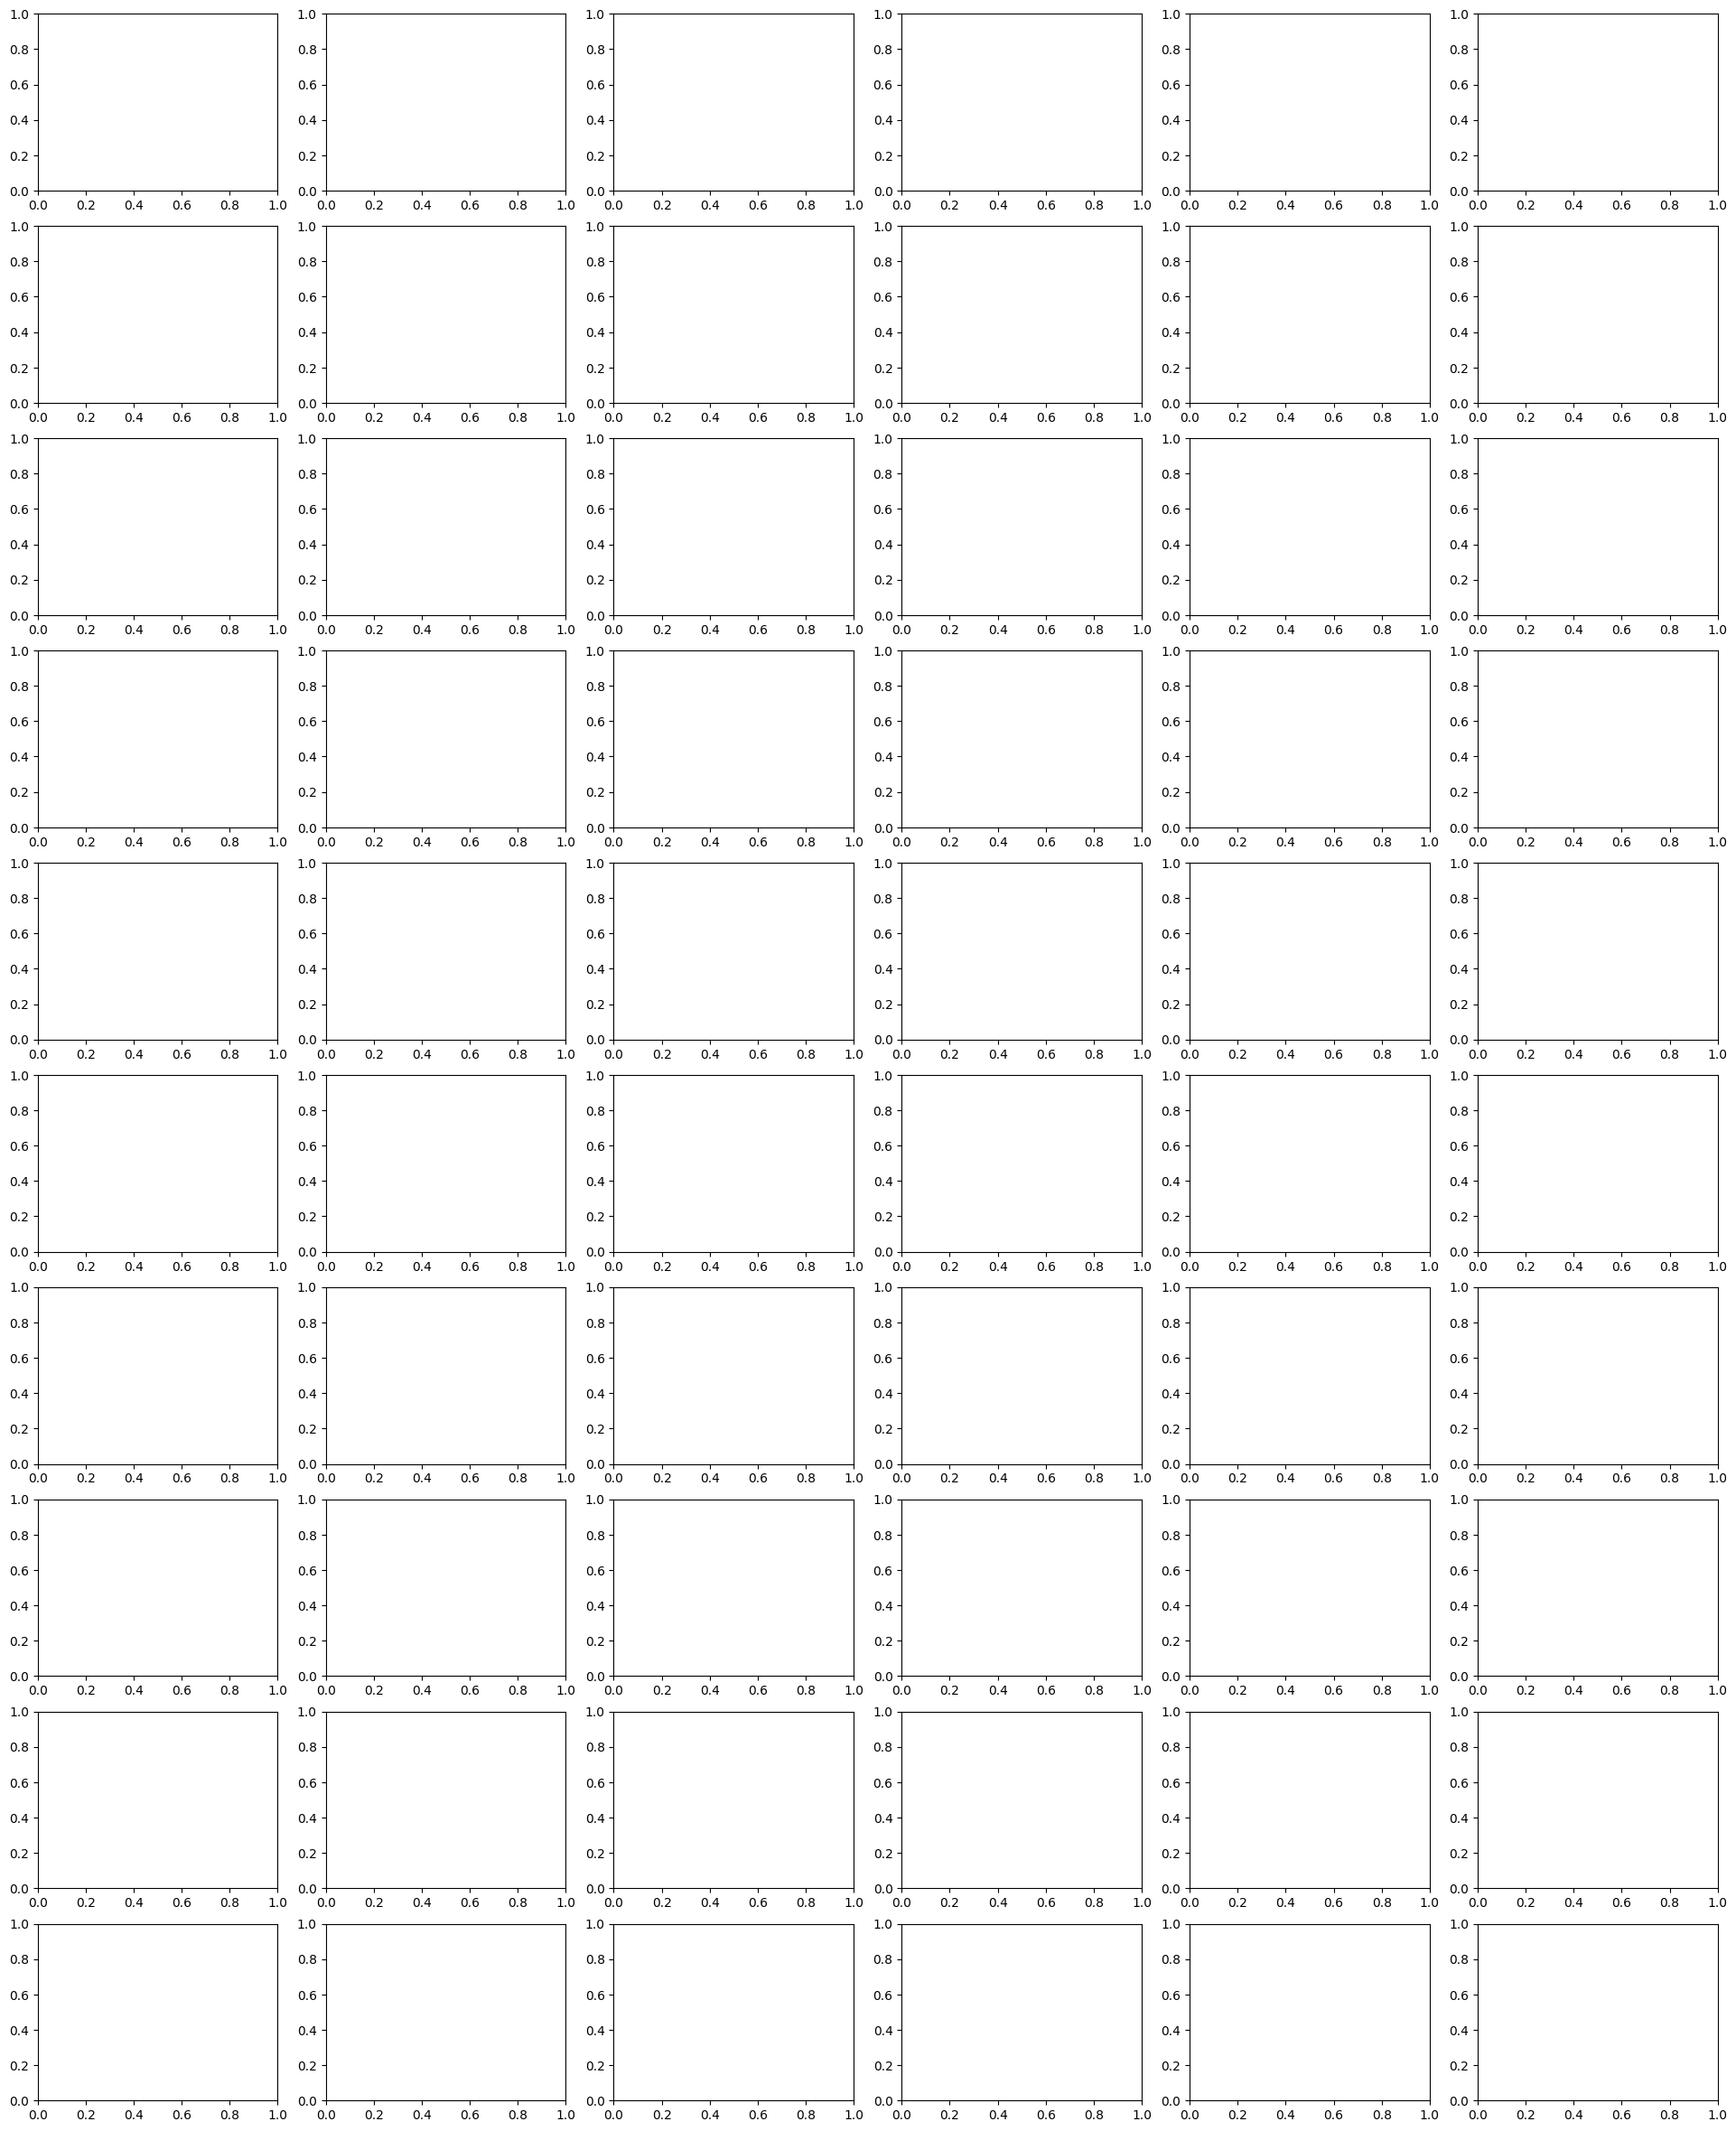

In [ ]:
# Plot Spectrograms (10 rates × 6 scales)
stm.plot.plt_spectrogram_grid(
    spec_data,
    n_cols=6,
    suptitle="Auditory Spectrograms — All 60 Ripples",
)

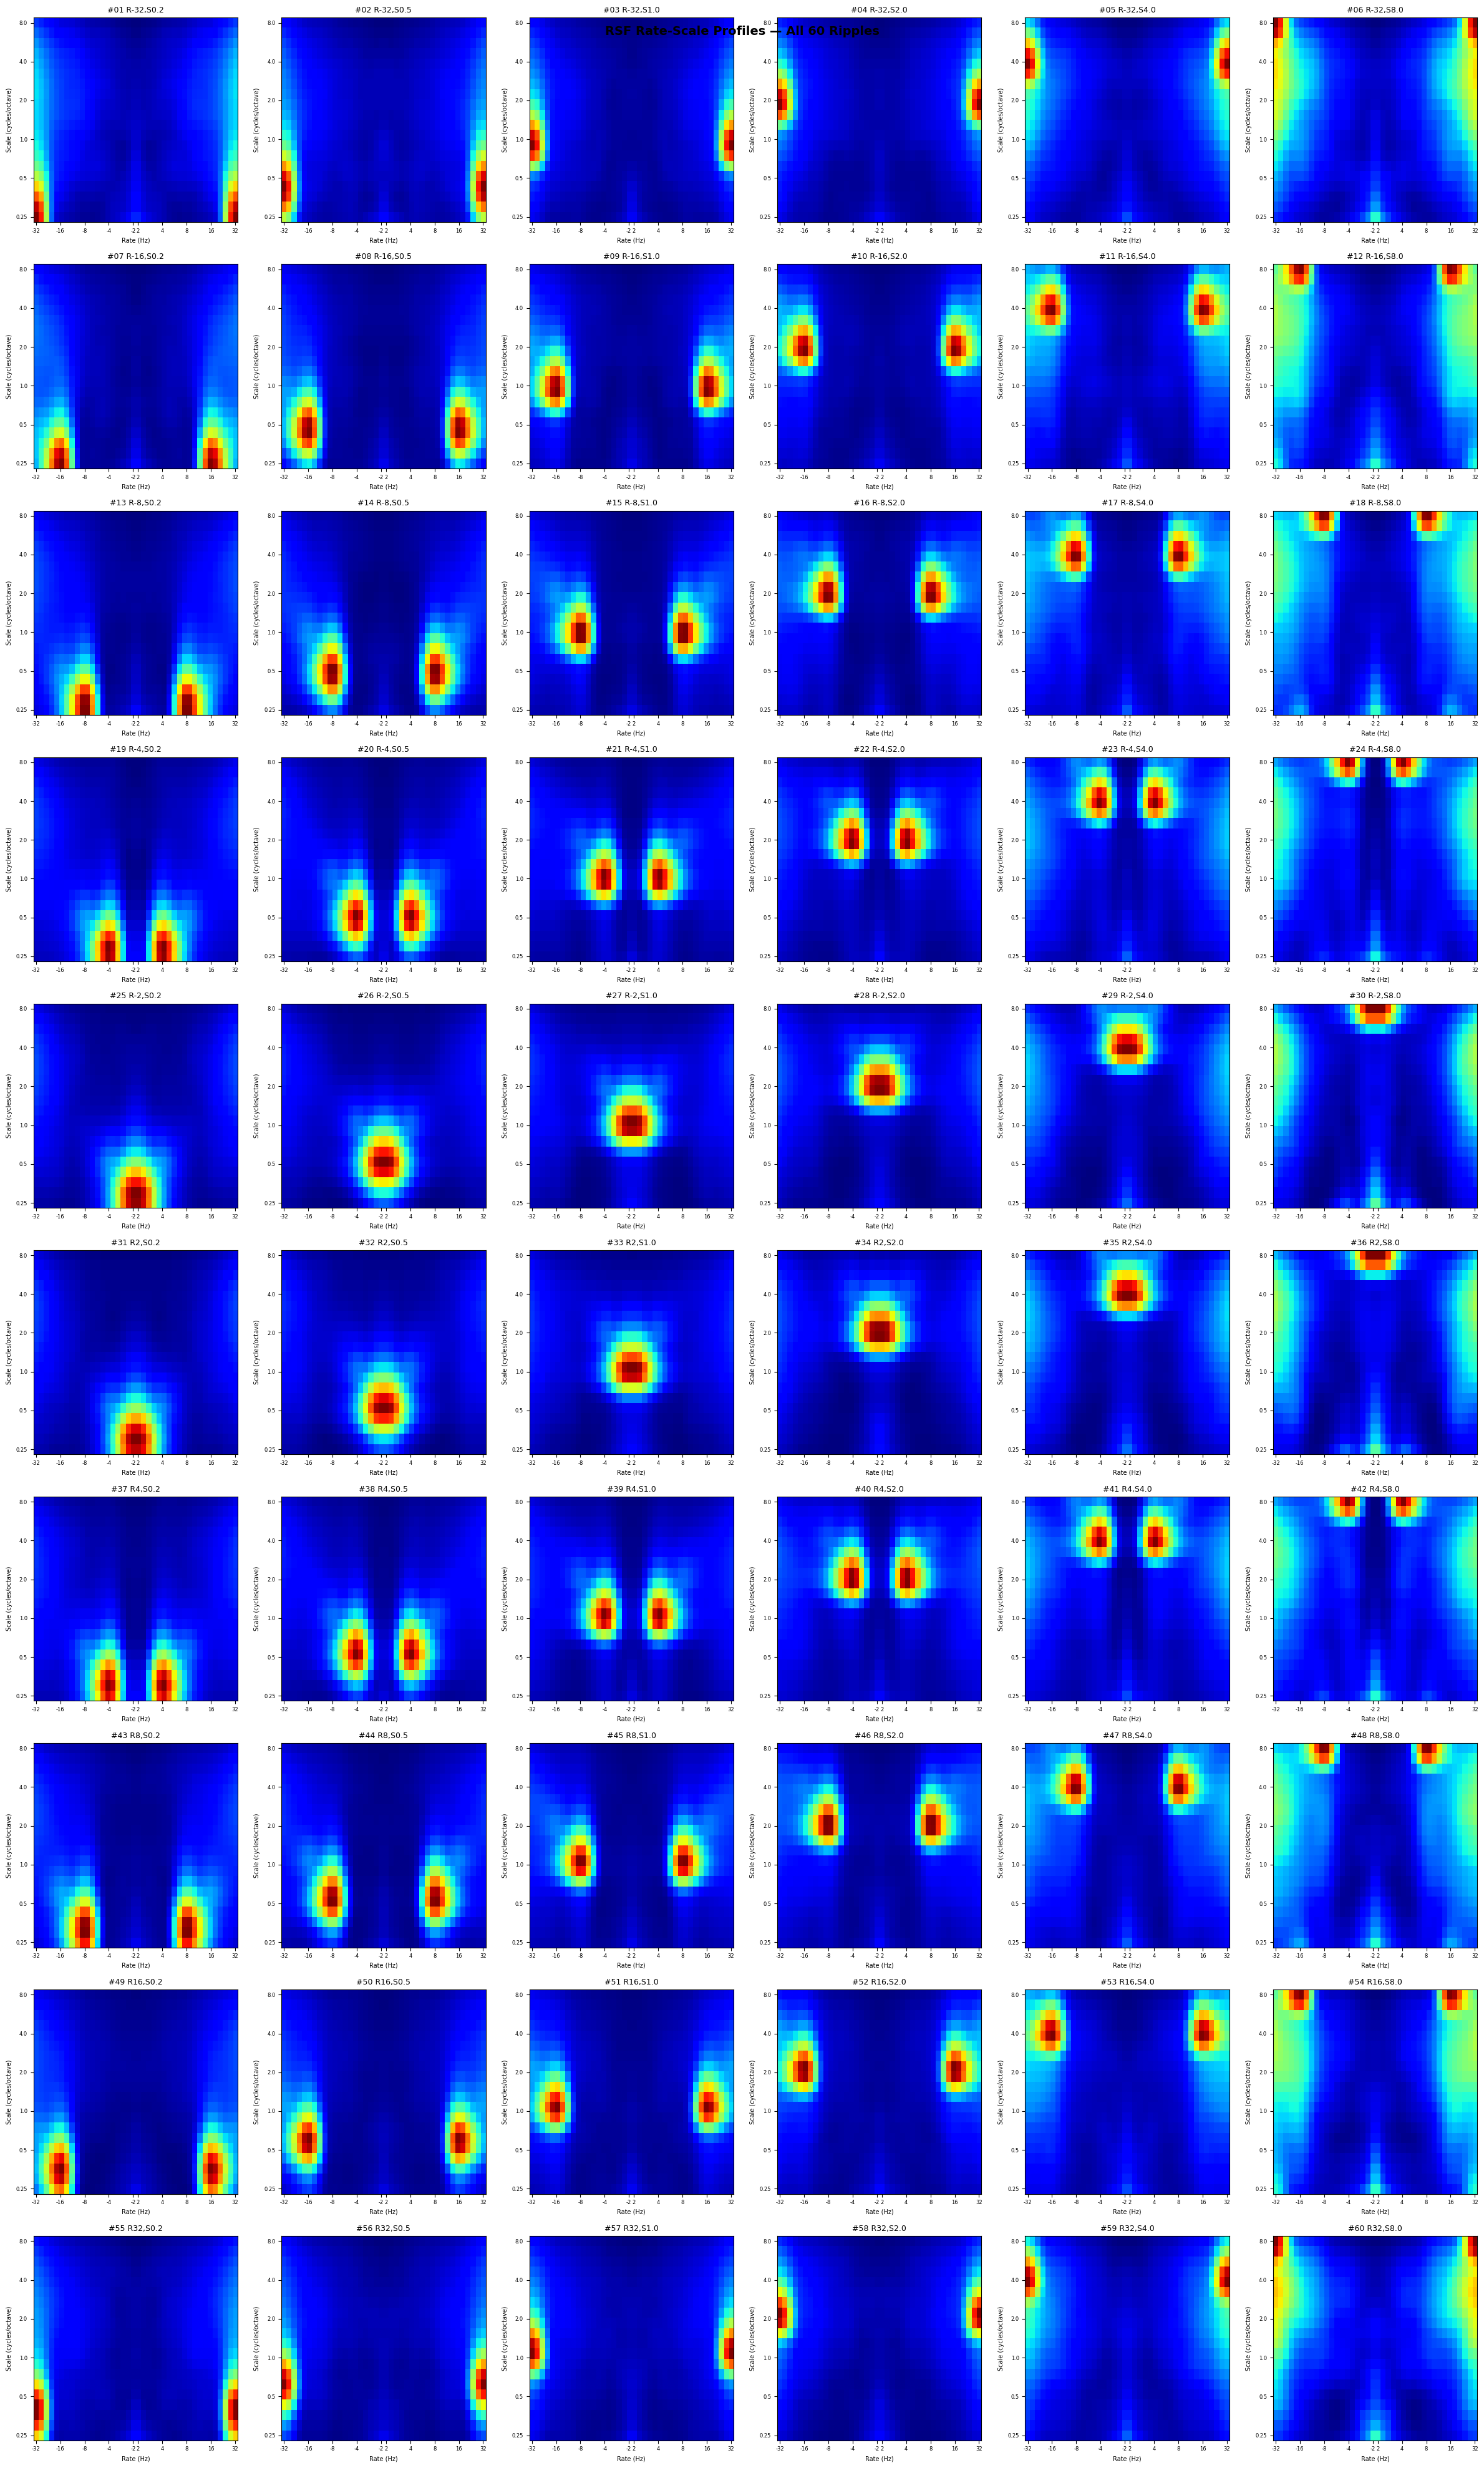

In [ ]:
# Plot RSFs (10 rates × 6 scales)
stm.plot.plt_rsf_grid(
    rsf_data,
    n_cols=6,
    fold=True,
    suptitle="RSF Rate-Scale Profiles — All 60 Ripples",
)